> 🚨 **Folders required before running this Notebook: Builing Block `.xyz` Files**

- `NODE_FILE` *(.xyz, required)*  
  File containing the node fragment (higher-connectivity building unit).  
  **Location:** `0_node/` directory  
  **Constraint:** For default settings exactly one `.xyz` file must be present in this directory. Otherwise the exact path (e.g `0_node/example_node.xyz"` has to be provided as input)

- `LINKER_FILE` *(.xyz, required)*  
  File containing the linker fragment (lower-connectivity building unit).  
  **Location:** `0_linker/` directory  
  **Constraint:** Exactly one `.xyz` file must be present in this directory. Otherwise the exact path (e.g `0_linker/example_linker.xyz"` has to be provided as input)  


> 🚨 **Building Block Requirements**
>
> - **Dummy atoms are required at every intended connection site.**  
>   Each position at which a node–linker bond will be formed in the final COF must be marked by a dummy atom in the input building block.
>
> - **Dummy atom encoding**
>   - `He` = connection site for a single bond  
>   - `Se` = connection site for a double bond
>
> - **Consistency requirement**  
>   The dummy atom type must match the selected `BOND_TYPE` used later in the workflow.  
>   For example:
>   - if `BOND_TYPE = single`, all connection sites must be marked with `He`
>   - if `BOND_TYPE = double`, all connection sites must be marked with `Se`
>
> - **Important**  
>   Dummy atoms are used only to define the connection sites during construction. They do not represent real atoms in the final COF structure.

In [1]:
import coflandscaper as cl

/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


### General Settings & Options

#### Structural Parameters

- `TOPOLOGY` *(str, required, default: None)*  
  Defines the underlying network topology.  
  **Allowed values:** `hcb`, `sql`  

- `BOND_TYPE` *(str, required, default: None)*  
  Specifies the bond type used to connect node and linker fragments.  
  **Allowed values:** `single`, `double`  
  **Constraint:** Must be consistent with the dummy atoms used in the input structures:  
  - `single` → **He**  
  - `double` → **Se**  
  **Note:** Mismatches may result in incorrect structure generation or runtime errors.

#### Naming Parameters

- `COF_NAME` *(str, required, default: None)*  
  Unique identifier for the generated structure.  
  All output files and directories will be named using this value.  
  **Constraints:**  
  - Should be unique within the working directory.  
  - Avoid spaces and special characters for compatibility.  

#### Stacking Parameters

- `MODE` *(str, required, default: None)*  
  Defines the stacking mode(s) to be generated.  
  **Allowed values:**  
  - `incl` → inclined stacking  
  - `serr` → serrated stacking  
  - `both` → generate both stacking modes  

  **Behavior:**  
  Selecting `both` will generate both configurations sequentially and store them in the corresponding output structure.

In [2]:
TOPOLOGY = "hcb"
BOND_TYPE = "single"
COF_NAME = "COF-1"
MODE = "both"

### Single-Layer COF Construction & Pre-Optimization

This step generates the single-layer COF structure and performs a MACE-pre-optimization.

> **Practical note:** If the node and linker fragments are strongly non-planar, the generated stacking matrix can contain strained or sterically congested geometries. Starting from relatively planar building units is therefore recommended, followed by relaxation of the assembled framework. Because the isolated single-layer model has more conformational freedom than the final stacked COF, the preoptimized layer may twist more strongly than the corresponding bulk structure. The generated matrix should be inspected for unphysical close contacts before downstream screening.

In [3]:
# Construction (Default)
builder = cl.BuildCOF2D()
builder.build(topo=TOPOLOGY, bond_type=BOND_TYPE, cof_name=COF_NAME)

>>> == Min RMSD of (node type: 0, node bb: example-node): 9.36E-05
>>> Pre-location at node slot 0, (node type: 0, node bb: example-node), RMSD: 9.36E-05
>>> Pre-location at node slot 1, (node type: 0, node bb: example-node), RMSD: 9.36E-05
>>> Topology optimization starts.
>>> MESSAGE: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
>>> SUCCESS: True
>>> ITER: 10
>>> OBJ: 0.000
>>> Location at node slot 0, (node type: 0, node bb: example-node), RMSD: 8.04E-05
>>> Location at node slot 1, (node type: 0, node bb: example-node), RMSD: 8.29E-05
>>> Start placing edges.
/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/spatial/transform/_rotation.py:2586: UserWarning: Optimal rotation is not uniquely or poorly defined for the given sets of vectors.
  q, rssd, sensitivity = backend.align_vectors(a, b, weights, return_sensitivity)
>>> Start finding bonds in generated framework.
>>> Start finding bonds in building blocks.
>>> Start fi

['COF-1/1_COF-1_single_layer/COF-1_unopt.cif']

In [4]:
# Pre-Optimization (Default)
preopt = cl.MaceOpt()
preopt.run_preopt(cof_name=COF_NAME)

       Step     Time          Energy          fmax
LBFGS:    0 08:26:12   -35219.691403        2.531200


/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 3.004580711214139e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:    1 08:26:13   -35220.417710        0.979092


/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 3.008101018908673e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:    2 08:26:14   -35220.625735        0.978249


...

/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 2.963018270493644e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:   21 08:26:29   -35222.439673        0.011231


/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 2.938880574419587e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:   22 08:26:30   -35222.439713        0.008715
Converged


True

### ILD × ILS Structure Matrix Generation

This step generates stacked COF structures by systematically varying:

- **Interlayer Distance (ILD)** along the $z$-axis *(default range: 3.0--4.0 Å in steps of 0.1 Å)*  
- **Interlayer Slipping (ILS)** within the $xy$-plane *(default range: 0.0 Å (AA) to the AB limit in steps of 1.0 Å, with automatic alignment along the AA → AB direction)*

The input structure is the pre-optimized single-layer (AA stacking with large interlayer distance).  
This step converts it into physically meaningful bulk stacking configurations.

  Generated stacked structures organized by mode:  
  - `.../serr/` → serrated stacking configurations  
  - `.../incl/` → inclined stacking configurations  

These structures are intended for subsequent single-point energy evaluations and energy landscape analysis.

In [5]:
# Defaults
matrix = cl.CreateMatrix()
matrix.run(cof_name=COF_NAME, topo=TOPOLOGY, mode=MODE)

### MACE Single-Point Energy Evaluation

This step computes single-point energies for generated structures using `MaceSP` (no geometry optimization).

Single-point energies are written ro `{COF_NAME}_sp_energies_{serr|incl}.csv` in `COF_NAME/3_{COF_NAME}_landscape/`  

In [ ]:
# Defaults
sp = cl.MaceSP()
sp.run_mode(cof_name=COF_NAME, mode=MODE)

### Potential Energy Landscape (PES)

This step plots an approximate stacking potential energy surface by mapping the relative energies of the generated ILD/ILS structure matrix as a function of interlayer distance (ILD) and interlayer slipping (ILS).

Because no full structural relaxation is performed at this stage, the PES is treated as a reduced-dimensional screening model rather than a full description of the underlying high-dimensional energy landscape. Within this approximation, it provides a qualitative to semi-quantitative representation of the relative stability of different stacking arrangements and serves to identify candidate minima for subsequent refinement by full geometry optimization.

---

- `show` *(bool, optional, default: `False`)*  
  If `True`, displays interactive plot windows.  

- PES plots `pes_{COF_NAME}_{serr|incl}_{plot_mode}.png` default written to:  
  `COF_NAME/3_{COF_NAME}_landscape/`

<Figure size 1000x600 with 0 Axes>

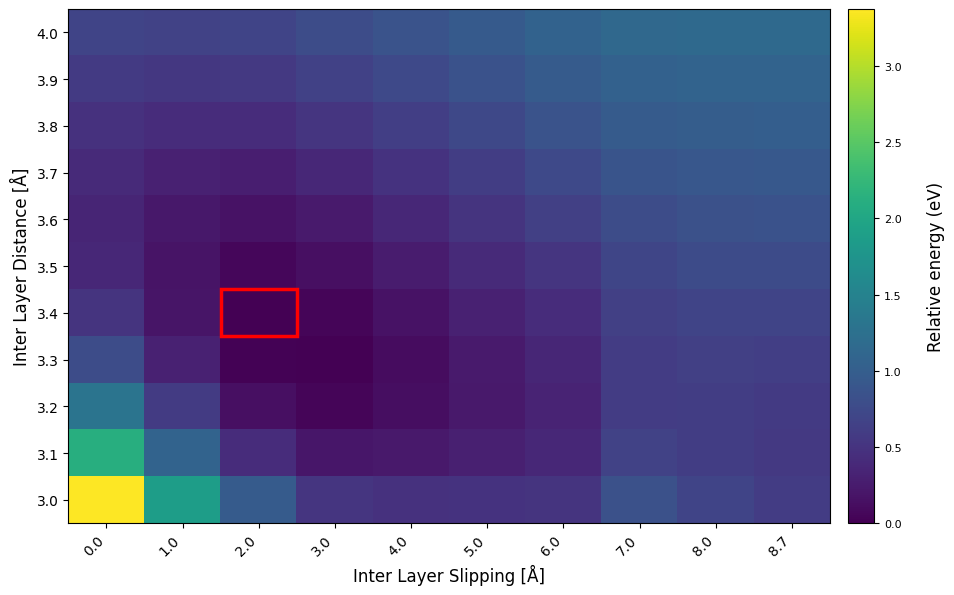

Saved: COF-1/3_COF-1_landscape/pes_COF-1_serr_heatmap.png


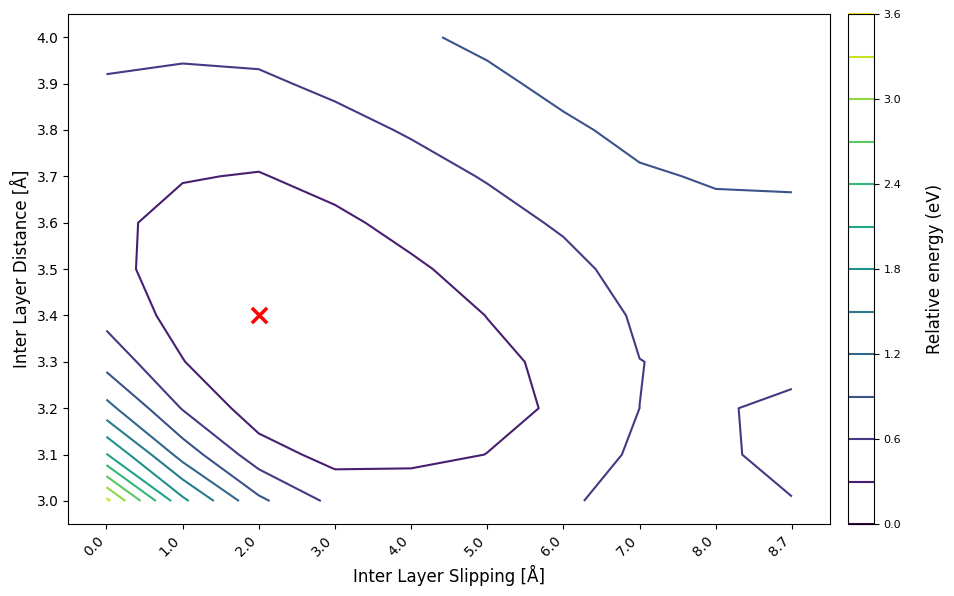

Saved: COF-1/3_COF-1_landscape/pes_COF-1_serr_isolines.png


<Figure size 1000x600 with 0 Axes>

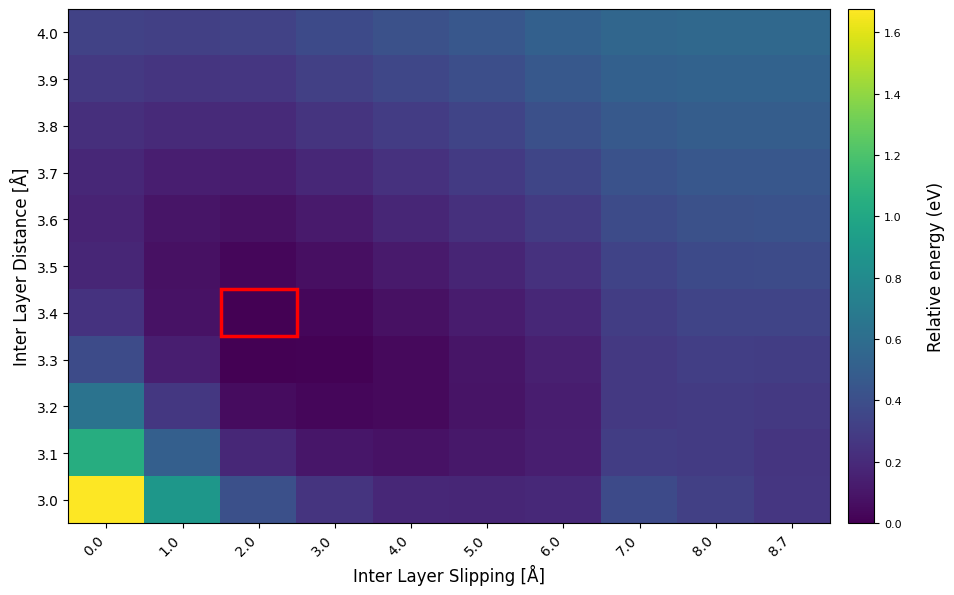

Saved: COF-1/3_COF-1_landscape/pes_COF-1_incl_heatmap.png


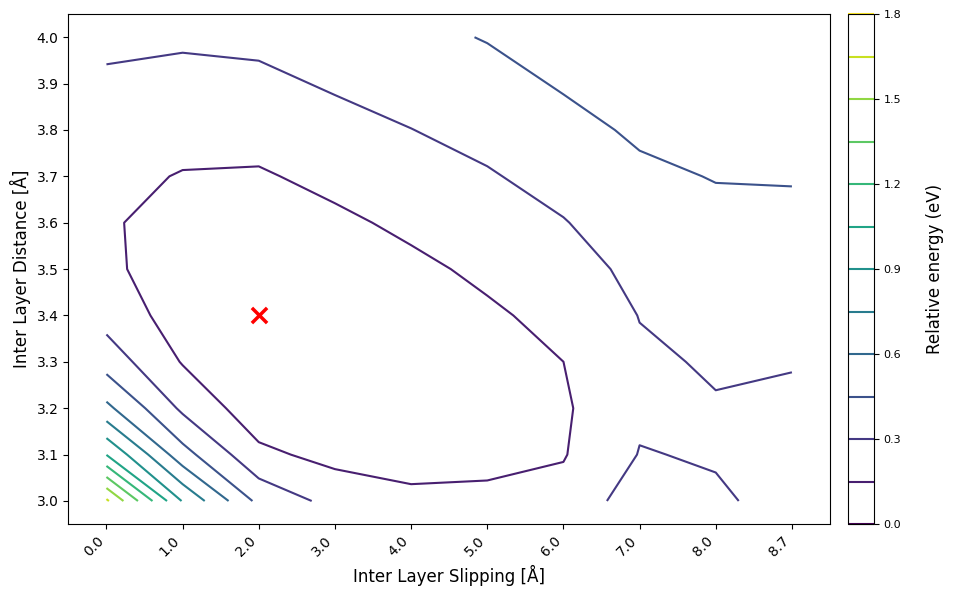

Saved: COF-1/3_COF-1_landscape/pes_COF-1_incl_isolines.png


In [7]:
# Defaults
landscape = cl.Landscape()
landscape.run_mode(cof_name=COF_NAME, mode=MODE, show= True)

### Structure Selection for Optimization

This step selects candidate structures corresponding to automatically detected local or gloabl minima are copies them into dedicated folders.

In [8]:
# Defaults, auto-selected global minima structures
selector = cl.SelectCofs()
selector.run_mode(cof_name=COF_NAME, mode=MODE)


Selected ILD/ILS pairs (Serrated):
 ILD (Å)  ILS (Å)
     3.4      2.0

Selected ILD/ILS pairs (Inclined):
 ILD (Å)  ILS (Å)
     3.4      2.0


### MACE Geometry Optimization

This step performs geometry optimizations of selected stacking structures using `MaceOpt`.

`MaceOpt` uses ASE `FrechetCellFilter` + `LBFGS`, writes optimized CIF files, and can write a combined energy CSV (`{COF_NAME}_opt_energies_per_layer.csv`).

  Optimized structures (`.cif`) and optional energies CSV are written to:  
  `COF_NAME/4_{COF_NAME}_optimization/`

In [ ]:
# Defaults
opt = cl.MaceOpt()
opt.run_mode(cof_name=COF_NAME, mode=MODE)

### Analysis & Visualization

This step analyzes optimized structures by computing interlayer distance (ILD) and interlayer slipping (ILS) from the optimized structures, and writing a summary CSV for comparison across stacking configurations.

In addition, structures can be visualized using an interactive viewer.

In [10]:
# Defaults
analyzer = cl.AnalyzeStacking()
analyzer.analyze(cof_name=COF_NAME, mode=MODE)

Serrated:
 ILD (Å)  ILS (Å)  Erel (eV)
    3.4      2.1        0.0
Inclined:
 ILD (Å)  ILS (Å)  Erel (eV)
    3.3      2.0        0.0


In [11]:
# Defaults
visualizer = cl.VisualizeCOF()
visualizer.visualize_cof(cof_name=COF_NAME, mode=MODE)

Serrated | cof-1_z33_L020_serr.cif: ILD = 3.35 Å, ILS = 2.12 Å


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Inclined | cof-1_z33_L020_incl.cif: ILD = 3.31 Å, ILS = 2.00 Å


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

[<py3Dmol.view at 0x3707877a0>, <py3Dmol.view at 0x3708936e0>]

### PXRD Pattern Generation

This step simulates PXRD patterns from optimized CIF structures and writes per-structure `.xy` files.

---

#### Parameters

- `wavelength` *(str, optional, default: `CuKa`)*  
  X-ray source line used for simulation.  
  **Allowed values:** `CuKa`, `MoKa`, `CrKa`, `FeKa`, `CoKa`, `AgKa`  
  Choose this to match your instrument/source.

- `two_theta_range` *(tuple[float, float], optional, default: `(1.5, 60.0)`)*  
  Angular simulation window in degrees for generated `.xy` data.

- PXRD data (`.xy`) default written to:  
  `COF_NAME/5_{COF_NAME}_analysis/pxrd_xy/{serr|incl}/`


In [12]:
pxrd = cl.PXRD(wavelength="CuKa", two_theta_range=(1.5, 60.0))
pxrd.run(cof_name=COF_NAME, mode=MODE)

{'serr': 'COF-1/5_COF-1_analysis/pxrd_xy/serr',
 'incl': 'COF-1/5_COF-1_analysis/pxrd_xy/incl'}

### PXRD Plot

This step provides two plotting helpers:

- `plot_sim`  
  Stacked simulated PXRD patterns from `pxrd_xy/{serr|incl}` (or `pxrd_xy_dft/{serr|incl}` when `dft=True`).

- `plot_sim_vs_exp`  
  One experimental `.xy` file compared against every simulated `.xy` file in its own row.

#### Parameters

- `exp_xy_file` *(str or Path, optional, default: None)*  
  Path to the experimental `.xy` file.  
  **Default behavior:** If not provided, the folder `experimental_pxrd` (in the current directory) is searched for exactly one `.xy` file. If multiple `.xy` files exist, you must specify the exact path explicitly.  

- `xy_folder` for `plot_sim` or `simulated_xy_folder` for `plot_sim_vs_exp` *(str or Path, optional, default: None)*  
  Path to the simulated `.xy` files in their `MODE` subfolders.  
  **Custom labels:** To change the label displayed in the plot, simply rename your `.xy` file before passing it.

- `xlim` *(tuple[float, float], optional, default: `(1.5, 60.0)`)*  
  X-axis bounds as minimum and maximum 2θ range [º].

#### Output

- `plot_sim` writes `{COF_NAME}_sim_{serr|incl}.png`.  
- `plot_sim_vs_exp` writes `{COF_NAME}_{serr|incl|both}.png`.

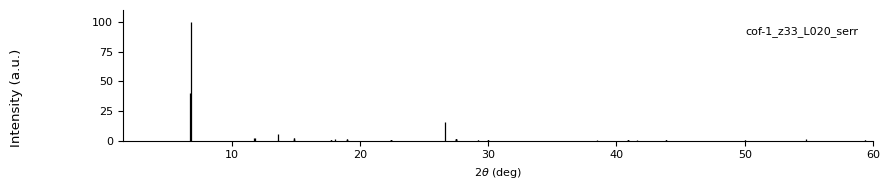

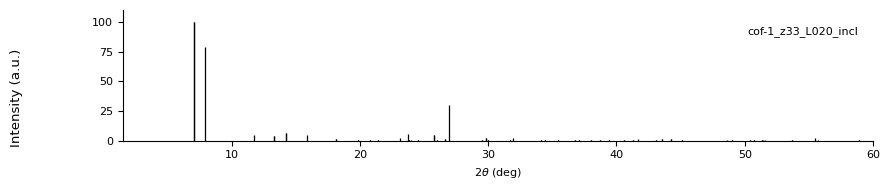

{'serr': 'COF-1/5_COF-1_analysis/COF-1_sim_serr.png',
 'incl': 'COF-1/5_COF-1_analysis/COF-1_sim_incl.png'}

In [13]:
pxrd = cl.PXRD()
pxrd.plot_sim(
    cof_name=COF_NAME,
    mode=MODE,
    xy_folder=None,
    xlim=(1.5, 60.0),
)

In [ ]:
# For an example of `PXRD.plot_sim_vs_exp()`, please refer to the hybrid workflow example. Experimental `.xy` data are not available for COF-1, so this functionality cannot be demonstrated here.